In [119]:
from pathlib import Path

def downloaded_doc_dir(csv_path: str | Path, document_id: str) -> Path:
    csv_path = Path(csv_path.replace('_all_text', '')).resolve()
    source_dir = csv_path.parent
    csv_name = csv_path.stem              # e.g. "notice", "public_submission"
    return source_dir / "downloaded_content" / csv_name / document_id

In [120]:
from pathlib import Path
import asyncio
import random
import textwrap
import pandas as pd
from openai import AsyncOpenAI
import nest_asyncio  # type: ignore
import glob, os 
import asyncio
import pandas as pd
from openai import AsyncOpenAI
import nest_asyncio
import glob
import asyncio
import random
import pandas as pd
from openai import AsyncOpenAI
import nest_asyncio
from tqdm.asyncio import tqdm

# 1. Setup & Config
nest_asyncio.apply()
client = AsyncOpenAI(api_key=open('/Users/spangher/.openai-reglab-project-key.txt').read().strip())
parsed_files = glob.glob('../data/bulk_downloads/**/*_all_text.csv', recursive=True)

OPENAI_MODEL = 'gpt-5-mini'
MAX_CONCURRENT = 50  # Flex tier can handle high concurrency
WINDOW_CHARS = 12000
MAX_SAMPLES_PER_ROW = 2 
ROWS_TO_SAMPLE_PER_CSV = 20
sem = asyncio.Semaphore(MAX_CONCURRENT)

# 2. Your Preserved Functions
def iter_sample(text, window_chars=WINDOW_CHARS, samples_per_file=MAX_SAMPLES_PER_ROW):
    if not text or not isinstance(text, str):
        return []
    windows = [text[i:i + window_chars].strip() for i in range(0, len(text), window_chars)]
    windows = [w for w in windows if w]
    random.shuffle(windows)
    return windows[:samples_per_file]

PROMPT_TEMPLATE = """You are an expert legal assistant.

I am trying to determine if the following text from a regulatory agency is responding to comments submitted during the notes & comments process.
I will show you two random snippets of text from a regulatory agency's filing. 
Please assess whether the following regulatory text includes a concrete response to a comment by a member of the public during the notes & comments process.
Answer strictly with "yes" or "no".

<regulatory_text>
{snippet}
</regulatory_text>

Your response:"""

# 3. The Core Async Function
async def request_label(snippet, source_file, doc_id):
    async with sem:
        try:
            response = await client.chat.completions.create(
                model=OPENAI_MODEL,
                service_tier="flex",
                messages=[
                    {"role": "system", "content": "Return yes or no."},
                    {"role": "user", "content": PROMPT_TEMPLATE.format(snippet=snippet)}
                ],
            )
            answer = response.choices[0].message.content.strip().lower()
            return {
                "doc_id": doc_id,
                "file_on_disk": downloaded_doc_dir(csv_path= source_file, document_id=doc_id),
                "file": source_file,
                "label": 1 if answer.startswith('y') else 0,
                "snippet": snippet[:100] + "..." # Storing a preview
            }
        except Exception as e:
            return {"file": source_file, "error": str(e)}

In [121]:
# 4. Preprocessing: The "Outer Loop"
all_tasks = []
all_dfs = []
files_to_process = list(filter(lambda x: 'public_submission' not in x, parsed_files))
for file_path in tqdm(files_to_process, desc="Preprocessing CSVs"):
    # Load CSV once
    df = pd.read_csv(file_path).drop_duplicates('Document ID')
    all_dfs.append(
        df.assign(filepath=file_path)
    )
    
    # Sample up to `ROWS_TO_SAMPLE_PER_CSV` rows
    n_rows = min(len(df), ROWS_TO_SAMPLE_PER_CSV)
    samples = df.sample(n_rows)
    
    for _, row in samples.iterrows():
        # Extract text from the first column
        raw_text = str(row['canonical_text'])
        
        # Generate windows using your window logic
        windows = iter_sample(raw_text)
        
        for window in windows:
            all_tasks.append(request_label(window, file_path, row['Document ID']))
    
# 5. Execution
print(f"Starting async queue for {len(all_tasks)} snippets...")
results = await tqdm.gather(*all_tasks, desc="Querying OpenAI (Flex)")

# 6. Final Data
df_final = pd.DataFrame([r for r in results if "label" in r])
print(f"\nDone! Processed {len(df_final)} successful labels.")

Preprocessing CSVs: 100%|███████████████████████████████████████████████████████████████| 576/576 [00:28<00:00, 19.86it/s]


Starting async queue for 13973 snippets...


Querying OpenAI (Flex): 100%|███████████████████████████████████████████████████████| 13973/13973 [11:46<00:00, 19.78it/s]


Done! Processed 13973 successful labels.


In [122]:
df_final = df_final.assign(file_type=lambda df: df['file'].str.split('/').str.get(-1).str.replace('_all_text.csv', ''))

In [123]:
(
    df_final
     [['file_type', 'label']].value_counts()
     .unstack().fillna(0).astype(int)
)

label,0,1
file_type,,
notice,6128,208
proposed_rule,2977,346
proposed_rules,37,1
rule,3136,1056
rules,48,17
supporting_material,16,3


In [130]:
row_to_examine = (
    df_final
     .loc[lambda df: df['label'] == 1]
     .loc[lambda df: df['file'].str.contains('notice')]
     .iloc[0].to_dict()
     # ['snippet'].iloc[0]
)

In [131]:
row_to_examine

{'doc_id': 'MSHA-2018-0015-0013',
 'file_on_disk': PosixPath('/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/msha/msha_2020_2021/downloaded_content/notice/MSHA-2018-0015-0013'),
 'file': '../data/bulk_downloads/msha/msha_2020_2021/notice_all_text.csv',
 'label': 1,
 'snippet': '<<COMMENT 1>>\n2020-05-27T04:00Z\n\nfalse\n\n<<COMMENT 2>>\n<<PAGE 1>>\n31812 \nFederal Register / Vol. 85, ...',
 'file_type': 'notice'}

In [132]:
full_df = pd.concat(all_dfs)

In [127]:
training_df = full_df.merge(df_final, left_on='Document ID', right_on='doc_id')[['canonical_text', 'label']]

In [149]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

stratify_series = training_df['label'] if training_df['label'].nunique() > 1 else None
train_df, test_df = train_test_split(
    training_df,
    test_size=0.2,
    stratify=stratify_series,
)

In [150]:
balanced_train_df = pd.concat([
    train_df.loc[lambda df: df['label'] == 1],
    train_df.loc[lambda df: df['label'] == 0].sample(n=len(train_df.loc[lambda df: df['label'] == 1])),
]).sample(frac=1)

In [152]:
bow_lr = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1, 2), min_df=.05, max_df=.5, max_features=50_000)),
    ('clf', LogisticRegression(max_iter=2000, solver='liblinear', verbose=True)),
])
bow_lr.fit(balanced_train_df['canonical_text'], balanced_train_df['label'])
test_pred = bow_lr.predict(test_df['canonical_text'])
print(classification_report(test_df['label'], test_pred, digits=3))
response_classifier = bow_lr

[LibLinear]iter  1 act 2.912e+02 pre 2.445e+02 delta 1.961e-02 f 1.910e+03 |g| 2.275e+05 CG  10
cg reaches trust region boundary
iter  2 act 1.537e+02 pre 1.228e+02 delta 2.978e-02 f 1.619e+03 |g| 7.516e+04 CG   8
cg reaches trust region boundary
iter  3 act 1.411e+02 pre 1.212e+02 delta 3.642e-02 f 1.465e+03 |g| 4.550e+04 CG   8
cg reaches trust region boundary
iter  4 act 1.182e+02 pre 1.193e+02 delta 3.802e-02 f 1.324e+03 |g| 4.475e+04 CG  10
cg reaches trust region boundary
iter  5 act -1.499e+02 pre 1.298e+02 delta 1.200e-02 f 1.206e+03 |g| 1.693e+04 CG  11
cg reaches trust region boundary
iter  5 act -3.274e+01 pre 6.643e+01 delta 4.778e-03 f 1.206e+03 |g| 1.693e+04 CG   7
cg reaches trust region boundary
iter  5 act 1.074e+01 pre 3.622e+01 delta 2.871e-03 f 1.206e+03 |g| 1.693e+04 CG   3
cg reaches trust region boundary
iter  6 act 9.803e+00 pre 2.691e+01 delta 1.841e-03 f 1.195e+03 |g| 2.870e+04 CG   3
cg reaches trust region boundary
iter  7 act -6.721e-01 pre 1.737e+01 delta 

In [153]:
y_proba = response_classifier.predict_proba(full_df['canonical_text'])

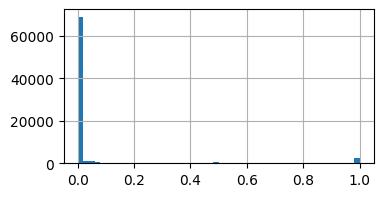

In [133]:
pd.Series(y_proba[:, 1]).hist(bins=50, figsize=(4,2));

In [154]:
c = pd.Series(y_proba[:, 1]).pipe(lambda s: s > .05).value_counts()
c.pipe(lambda s: s/ s.sum())

False    0.724904
True     0.275096
Name: count, dtype: float64

# Pull Chunks

In [160]:
full_df_w_pred = (
    full_df
         .reset_index(drop=True)
         .assign(y_pred=pd.Series(y_proba[:, 1]).pipe(lambda s: s > .05).values)
         .assign(canonical_text=lambda df: df['canonical_text'].str.replace(r'<<COMMENT \d+>>', '', regex=True))
)

In [161]:
full_df_w_pred_to_predict = full_df_w_pred.loc[lambda df: df['y_pred'] | (df['Document Type'] == 'Rule')]

In [163]:
full_df_w_pred_to_predict.to_pickle('2026-02-10__full-notices-rules-proposals-w-preds.pkl')

# extract info

In [5]:
PULL_CHUNKS_PROMPT ="""
  You are a helpful legal assistant. I will show you a government document that I think contains responses to comments submitted by members of the public.

  Your task is to identify passages where the agency is directly responding to comments.
  There may be multiple such passages, each referring to a specific comment or a group of comments. Or none at all.

  You should:
  - Find text where the document describes what commenters said
    (e.g., “Several commenters argued that…”, “One commenter stated that…”). 
    Be sure you're correctly identifying commenters engaging in notes and comment (i.e. from the public), 
    not references to government officials who didn't comment.
  - For each such description, find the corresponding text where the agency responds
    to that position (often in the same paragraph or immediately following).
  - Ignore text that only mentions the comment-gathering process in general
    (e.g., “The agency received 300 comments”) if it does not substantively describe
    comment content and an agency response.
  - If the document doesn't contain ANY references to the comment, simply return an empty list.

  For each identified comment→response pair, extract and annotate it.

  Respond in the following JSON format (a list of objects):

  [
    {{
      "content_of_comment": "<text from the document that describes the commenter(s)’ position>",
      "summarized_content_of_comment": "<BRIEF summary of what the comment is about>",
      "response_to_comment": "<BRIEF summary of the agency’s response to that position>",
      "quoted_or_paraphrased": "quoted | paraphrased | unclear",
      "type_of_response": "agree | disagree | accepted | partially_accepted | unclear",
      "reference_scope": "single_comment | group_of_comments | unclear",
      "commenter_identifiers_text": "<any names or identifiers used for the commenters (e.g., organization names, “a coalition of X
  organizations”), copied from the document, or an empty string>",
      "response_engagement_type": "substantive_response | procedural_or_general_discussion | mentioned_without_substantive_response",
      "rule_change_outcome": "change_made | change_considered_but_not_made | no_change_discussed | unclear"
    }}
  ]

  Guidelines:
  - Return a valid JSON array only. Do not include extra commentary.
  - Each entry should capture one clear commenter position and the agency’s specific reply.
  - If no such passages exist, return an empty list [].

  Here is the document:

    <document>
    {input_text}
    </document>

    Your response:
"""

In [ ]:
import prompt_utils as p
import pandas as pd

In [2]:
full_df_w_pred_to_predict = pd.read_pickle('2026-02-10__full-notices-rules-proposals-w-preds.pkl')

In [6]:
summarized_responses = await p.process_batch(
    full_df_w_pred_to_predict['canonical_text'], 
    prompt_template=PULL_CHUNKS_PROMPT,
    model='gpt-5'
)

  0%|          | 0/26781 [00:00<?, ?it/s]

In [17]:
(full_df_w_pred_to_predict
 [['Document ID', 'Agency ID', 'Docket ID', 'Document Type', 'filepath']].reset_index(drop=True)
 .assign(summarized_response=summarized_responses)
 .to_csv('2026-02-10__comment-response-cache.csv')
)

In [117]:
summarized_responses = pd.read_csv('2026-02-09__comment-response-cache.csv', index_col=0).iloc[:, 0]

### LLM-assisted segmentation of multi-comment PDFs
We often find a single `public_submission` attachment that bundles many commenters. The cells below:
1. sentence-tokenize canonical comment text pulled from the `_all_text` exports,
2. gather GPT-labelled boundary sentences (start/end of a distinct commenter),
3. train a lightweight linear classifier on those labels, and
4. apply the classifier across the sampled corpus so we can identify likely comment splits without sending everything through the LLM.


In [20]:
from tqdm.notebook import tqdm
import random

In [21]:
import spacy
from pathlib import Path
import pandas as pd

BOUNDARY_BASE_DIR = Path("../data/bulk_downloads").resolve()
boundary_csvs = sorted(
    p for p in BOUNDARY_BASE_DIR.rglob("*_all_text.csv")
    if p.is_file() and "downloaded_content" not in str(p)
)
boundary_csvs = list(filter(lambda x: 'public_submission' in str(x), boundary_csvs))

In [30]:
! pip uninstall blingfire -y
! pip uninstall blingfire2 -y
! pip install -U blingfire2

Found existing installation: blingfire2 0.2.1
Uninstalling blingfire2-0.2.1:
  Successfully uninstalled blingfire2-0.2.1
  Using cached blingfire2-0.2.1-py3-none-any.whl.metadata (13 kB)
Using cached blingfire2-0.2.1-py3-none-any.whl (42.4 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [32]:
from blingfire import *

In [39]:
from blingfire import *
text = 'After reading this post, you will know: What "natural language" is and how it is different from other types of data. What makes working with natural language so challenging. [1]'
text_to_sentences(text).split('\n')

['After reading this post, you will know: What "natural language" is and how it is different from other types of data.',
 'What makes working with natural language so challenging. [1]']

In [68]:
print(f"Found {len(boundary_csvs)} canonical CSVs.")

SENTENCE_SAMPLE_FILES = None
SAMPLE_CSVS = len(boundary_csvs)
BOUNDARY_NLP = spacy.load('en_core_web_lg')
# BOUNDARY_NLP = spacy.blank('en')
if "sentencizer" not in BOUNDARY_NLP.pipe_names:
    BOUNDARY_NLP.add_pipe("sentencizer")

def iter_sentences(
    texts: list[str],
    batch_size: int = 32,
    method: str = 'bling',
    chunk_size: int = 340,
):
    iterator = tqdm(texts, position=1, leave=False, desc="Docs", disable=method != 'spacy' )
    if method == 'use_char_chunks':
        for text in iterator:
            text = text or ""
            chunks = [
                text[i : i + chunk_size].strip()
                for i in range(0, len(text), chunk_size)
            ]
            yield [chunk for chunk in chunks if chunk]
        return
        
    elif method == 'spacy':
        for doc in BOUNDARY_NLP.pipe(iterator, batch_size=batch_size):
            yield [sent.text.strip() for sent in doc.sents if sent.text.strip()]
    
    else:
        for text in iterator:
            text = text or ""
            chunks = text_to_sentences(text).strip().split('\n')
            yield [chunk for chunk in chunks if chunk]


sample_sentence_rows: list[dict] = []
for csv_path in tqdm(random.sample(boundary_csvs, SAMPLE_CSVS), position=0, leave=True, desc="CSVs"):
    df = (
        pd.read_csv(csv_path, dtype=str)
            .assign(comment_len=lambda df: df['canonical_text'].str.len())
            .sort_values('comment_len', ascending=False)
            .fillna("")
            .iloc[:SENTENCE_SAMPLE_FILES]
    )
    if "canonical_text" not in df.columns or "Document ID" not in df.columns:
        continue
        
    subset = (
        df.loc[lambda d: d["canonical_text"].str.strip().astype(bool)]
            [["Document ID", "canonical_text"]]
    )
    doc_ids = subset["Document ID"].tolist()
    texts = (
        subset["canonical_text"]
                    .str.replace('\n', ' ')
                    .str.replace('\s+', ' ')
                    .str.replace(r"PAGE\s*\d*", " ", regex=True)
                    .str.replace(r"COMMENT\s*\d*", " ", regex=True)
                    .str.replace(r"<", " ", regex=True)
                    .str.replace(r">", " ", regex=True)
                    .str.replace(r"\s+", " ", regex=True)
                    .str.replace(r"false\s*\d*", " ", regex=True)
    )
    for doc_id, sentences in zip(doc_ids, iter_sentences(texts, method='bling')):
        sample_sentence_rows.append({
            "csv_path": str(csv_path),
            "document_id": doc_id,
            "sentences": list(sentences),
        })

<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_73665/2050548026.py:58: SyntaxWarning: invalid escape sequence '\s'
  .str.replace('\s+', ' ')
/Users/spangher/miniconda3/lib/python3.12/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_lg' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Found 168 canonical CSVs.


CSVs:   0%|          | 0/168 [00:00<?, ?it/s]

In [69]:
sentence_df = pd.DataFrame(sample_sentence_rows)
# sentence_df.to_pickle('cache_comment_sentences_for_boundary_detection.pkl')
# sentence_df.to_pickle('cache_comment_chunks_for_boundary_detection.pkl')
sentence_df.to_pickle('cache_bling_comment_sentences_for_boundary_detection.pkl')

# Score Boundaries

In [73]:
import re
import os
os.environ['OPENAI_API_KEY'] = open('/Users/spangher/.openai-reglab-project-key.txt').read().strip()

In [74]:
import asyncio
import json
import random
import string
import textwrap

import nest_asyncio
from openai import AsyncOpenAI
from tqdm.auto import tqdm

nest_asyncio.apply()
boundary_client = AsyncOpenAI()

BOUNDARY_BATCH_SIZE = 3
BOUNDARY_MAX_BATCHES = 3
BOUNDARY_WINDOW_SIZE = 25
BOUNDARY_WINDOWS_PER_DOC = 5
BOUNDARY_CONCURRENCY = 20
_BOUNDARY_RNG = random.Random(x=120)

BOUNDARY_PROMPT = """You are reviewing numbered sentences from public comments. Sentences are in windows; e.g.,
  1a./1b./… are the first window, 2a./2b./… the second, etc.
  Return JSON like [{{"idx": "1a", "is_boundary": "yes/no"}}] covering every sentence you see.
  Mark a sentence as a boundary if it clearly contains the beginning of a new comment (new organization/person) or contains the end of one
  (signatures, closings). Only answer with JSON.
  
  <sentences>
 {input_text}
  </sentences>

  Your response:
  """

def _format_batch(df_batch: pd.DataFrame) -> tuple[str, dict[str, dict]]:
    sections = []
    index_map: dict[str, dict] = {}

    for global_window_idx, row in enumerate(df_batch.itertuples(), start=1):
        sentences = list(row.window_sentences)
        if not sentences:
            continue

        header = (
            f"Window {global_window_idx} "
            f"(document {row.document_id}, starting sentence #{row.window_start})"
        )
        lines = [header]
        for sent_idx, sentence in enumerate(sentences):
            label = f"{global_window_idx}{string.ascii_lowercase[sent_idx]}"
            lines.append(f"{label}. {sentence}")
            index_map[label] = {
                "csv_path": row.csv_path,
                "document_id": row.document_id,
                "sentence": sentence,
                "sentence_index": row.window_start + sent_idx,
                "sentence_offset": sent_idx,
                "window_start": row.window_start,
            }
        sections.append("\n".join(lines))

    prompt = BOUNDARY_PROMPT.format(input_text='\n'.join(sections))
    return prompt, index_map

def _extract_response_text(resp) -> str:
    for item in getattr(resp, "output", []) or []:
        if getattr(item, "type", None) == "message":
            chunks = []
            for content in getattr(item, "content", []) or []:
                text = getattr(content, "text", None)
                if text:
                    chunks.append(text)
            if chunks:
                return ''.join(chunks)
    raise RuntimeError(f"No text output from response (status={resp.status}, error={resp.error})")

async def label_sentence_batch(df_batch: pd.DataFrame) -> list[dict]:
    prompt, index_map = _format_batch(df_batch)
    resp = await boundary_client.responses.create(
        model="gpt-5-mini",
        input=[{"role": "user", "content": prompt}],
    )
    raw = _extract_response_text(resp)
    parsed = json.loads(raw)

    parsed_lookup = {
        str(item.get("idx", "")).strip(): item for item in parsed if item.get("idx")
    }

    results = []
    for label, meta in index_map.items():
        decision = parsed_lookup.get(label, {})
        is_boundary = str(decision.get("is_boundary", "no")).lower().startswith("y")
        results.append(
            {
                "csv_path": meta["csv_path"],
                "document_id": meta["document_id"],
                "sentence_index": meta["sentence_index"],
                "sentence_offset": meta["sentence_offset"],
                "window_start": meta["window_start"],
                "sentence": meta["sentence"],
                "is_boundary": is_boundary,
                "reason": decision.get("reason", ""),
            }
        )
    return results

def clean_sentence(s):
    s = re.sub(r'PAGE \d', ' ', s)
    s = re.sub(r'COMMENT \d', ' ', s)
    s = re.sub(r'<', ' ', s)
    s = re.sub(r'>', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'false \d', ' ', s)
    return s

async def collect_boundary_labels(sample: pd.DataFrame) -> pd.DataFrame:
    window_rows: list[dict] = []

    for row in tqdm(
        sample.itertuples(index=False), total=len(sample), desc="Scanning docs"
    ):
        sentences = list(row.sentences)
        if not sentences:
            continue

        max_start = max(len(sentences) - BOUNDARY_WINDOW_SIZE, 0)
        if max_start == 0:
            window_starts = [0]
        else:
            candidates = list(range(1, max_start + 1)) # the first sentence of the document is obviously a boundary sentence.
            _BOUNDARY_RNG.shuffle(candidates)
            window_starts = sorted(candidates[:BOUNDARY_WINDOWS_PER_DOC])

        for start_idx in window_starts:
            window = sentences[start_idx : start_idx + BOUNDARY_WINDOW_SIZE]
            window = list(map(clean_sentence, window))
            window = list(filter(lambda x: x.strip() != '', window))
            if not window:
                continue
            window_rows.append(
                {
                    "csv_path": row.csv_path,
                    "document_id": row.document_id,
                    "window_start": start_idx,
                    "window_sentences": window,
                }
            )

    if not window_rows:
        return pd.DataFrame()

    windows_df = pd.DataFrame(window_rows)

    iterator = range(0, len(windows_df), BOUNDARY_BATCH_SIZE)
    if not len(iterator):
        return pd.DataFrame()
    semaphore = asyncio.Semaphore(BOUNDARY_CONCURRENCY)

    async def _run_batch(df_slice: pd.DataFrame) -> list[dict]:
        async with semaphore:
            return await label_sentence_batch(df_slice)

    tasks = [
        asyncio.create_task(_run_batch(windows_df.iloc[start : start + BOUNDARY_BATCH_SIZE]))
        for start in iterator
    ]

    labeled_rows: list[dict] = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="LLM batches"):
        labeled_rows.extend(await coro)

    return pd.DataFrame(labeled_rows)

loop = asyncio.get_event_loop()
boundary_labels_df = loop.run_until_complete(
    collect_boundary_labels(
        pd.concat([
            # sentence_df.loc[lambda df: df['document_id'].str.contains('EPA')].sample(30),
            (sentence_df
                 .loc[lambda df: ~df['document_id'].str.contains('EPA')]
                 .assign(sent_len=lambda df: df['sentences'].str.len())
                 .sort_values('sent_len', ascending=False)
                 .head(2000)
                 .sample(80)
            ),
        ])
    )
)
boundary_labels_df.head()

Scanning docs:   0%|          | 0/80 [00:00<?, ?it/s]

LLM batches:   0%|          | 0/134 [00:00<?, ?it/s]

,csv_path,document_id,sentence_index,sentence_offset,window_start,sentence,is_boundary,reason
0,/Users/spangher/Projects/stanford-research/rfi...,FDA-2019-N-1482-4195,1047,0,1047,Int J Neuropsychopharmacol 2009; 24: 1-12. [70],False,
1,/Users/spangher/Projects/stanford-research/rfi...,FDA-2019-N-1482-4195,1048,1,1047,"Bhattacharyya S, Fusar-Poli P, Borgwardt S, et...",False,
2,/Users/spangher/Projects/stanford-research/rfi...,FDA-2019-N-1482-4195,1049,2,1047,Arch Gen Psychiatry 2009; 66(4): 442-51. [71],False,
3,/Users/spangher/Projects/stanford-research/rfi...,FDA-2019-N-1482-4195,1050,3,1047,"Borgwardt SJ, Allen P, Bhattacharyya S, et al....",False,
4,/Users/spangher/Projects/stanford-research/rfi...,FDA-2019-N-1482-4195,1051,4,1047,Biol Psychiatry 2008; 64(11): 966-73. [72],False,


In [75]:
boundary_labels_df['is_boundary'].value_counts()

is_boundary
False    9385
True      615
Name: count, dtype: int64

In [54]:
boundary_labels_df['sentence'] = boundary_labels_df['sentence'].str.replace(r'false \d*', '', regex=True)

In [82]:
boundary_labels_df.to_csv('boundary_cache_6.csv')

In [55]:
all_boundary_labels_df.loc[lambda df: df['sentence'].str.contains('Sincerely')].iloc[-2]['sentence']

'nal standards as strong as possible to help protect communities like mine from both the devastation of climate change and deadly air pollution emitted by fossil fuel plants. Sincerely, Sandy Rubin 5541 Ingleside Dr Roanoke, VA 24018 rubinsandykay@gmail.com (540) 685-3896 This message was sent by KnowWho, as a service provider, o'

In [18]:
import pandas as pd 
import glob

In [19]:
all_boundary_labels_df = pd.concat(list(map(lambda x: pd.read_csv( x, index_col=0), glob.glob('boundary_cache_*.csv'),))).reset_index(drop=True)

In [20]:
from sklearn.utils import resample
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

boundary_ready = (
    all_boundary_labels_df
        .dropna(subset=["sentence"])
        .assign(y=lambda d: d["is_boundary"].astype(int))
)

train_df, test_df = train_test_split(
    boundary_ready,
    test_size=0.2,
    stratify=boundary_ready["y"],
)

minority, majority = train_df[train_df["y"] == 1], train_df[train_df["y"] == 0]
balanced_majority = resample(majority, n_samples=len(minority), replace=len(majority) < len(minority))
train_df_balanced = pd.concat([minority, balanced_majority]).sample(frac=1).reset_index(drop=True)

boundary_clf = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000),
    LogisticRegression(max_iter=1000)
)
boundary_clf.fit(train_df_balanced["sentence"], train_df_balanced["y"])
test_pred = boundary_clf.predict(test_df["sentence"])
print(classification_report(test_df["y"], test_pred, digits=3))

              precision    recall  f1-score   support

           0      0.986     0.919     0.951      7864
           1      0.382     0.791     0.515       497

    accuracy                          0.912      8361
   macro avg      0.684     0.855     0.733      8361
weighted avg      0.950     0.912     0.925      8361



In [21]:
train_df['y'].value_counts()

y
0    31454
1     1986
Name: count, dtype: int64

In [22]:
# sentence_df = pd.read_pickle('cache_comment_chunks_for_boundary_detection.pkl')
sentence_df = pd.read_pickle('cache_bling_comment_sentences_for_boundary_detection.pkl')

In [24]:
import os 
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

def score_sentence_boundaries(
    df_sentences: pd.DataFrame,
    model,
    threshold: float = 0.55,
    batch_size: int = 1_000,
) -> pd.DataFrame:
    
    all_exploded_dfs: list[pd.DataFrame] = []
    iterator = range(0, len(df_sentences), batch_size)
    for start in tqdm(iterator, total=len(iterator), desc="Scoring batches", disable=True):
        exploded_sentence_df = (
            df_sentences
            .iloc[start : start + batch_size]
            .explode("sentences")
            .assign(
                sentence_index=lambda df: df.groupby(level=0).cumcount(),
                sentences=lambda df: (
                    df["sentences"]
                    .str.replace(r"PAGE \d", " ", regex=True)
                    .str.replace(r"COMMENT \d", " ", regex=True)
                    .str.replace(r"<", " ", regex=True)
                    .str.replace(r">", " ", regex=True)
                    .str.replace(r"\s+", " ", regex=True)
                    .str.replace(r"false\s*\d*", " ", regex=True)
                    .str.strip()
                    .fillna('')
                ),
            )
            .loc[lambda df: df["sentences"] != ""]
        )
        if exploded_sentence_df.empty:
            continue
        probs = model.predict_proba(exploded_sentence_df["sentences"].tolist())[:, 1]
        exploded_sentence_df["scores"] = probs.tolist()
        all_exploded_dfs.append(exploded_sentence_df)

    if not all_exploded_dfs:
        return pd.DataFrame(
            columns=df_sentences.columns.tolist()
            + ["sentence_index", "scores", "is_boundary_pred"]
        )

    full_exploded_df = pd.concat(all_exploded_dfs).reset_index(drop=True)
    return full_exploded_df.assign(
        is_boundary_pred=lambda df: (df["scores"] >= threshold).astype(int)
    )


def _emit_chunk(buffer, csv_path: str, chunk_idx: int) -> dict:
    sentences = [row.sentences for row in buffer]
    return {
        "csv_path": csv_path,
        "document_id": buffer[0].document_id,
        "chunk_index": chunk_idx,
        "sentence_start_index": buffer[0].sentence_index,
        "sentence_end_index": buffer[-1].sentence_index,
        "num_sentences": len(sentences),
        "chunk_text": " ".join(sentences).strip(),
    }


def _chunk_document(doc_df: pd.DataFrame, csv_path: str) -> list[dict]:
    doc_df = doc_df.sort_values("sentence_index").reset_index(drop=True)
    chunks: list[dict] = []
    buffer: list = []
    chunk_idx = 0
    pending_break = False

    for row in doc_df.itertuples(index=False):
        if pending_break and row.is_boundary_pred == 0:
            chunks.append(_emit_chunk(buffer, csv_path, chunk_idx))
            chunk_idx += 1
            buffer = []
            pending_break = False
        buffer.append(row)
        if row.is_boundary_pred == 1:
            pending_break = True

    if buffer:
        chunks.append(_emit_chunk(buffer, csv_path, chunk_idx))

    return chunks


def chunk_and_save(sentence_df: pd.DataFrame, model, output_dir: str | Path | None = None) -> None:    
    for csv_path, df_csv in tqdm(sentence_df.groupby("csv_path")):
        src_path = Path(csv_path)
        target_dir = Path(output_dir) if output_dir else src_path.parent
        target_dir.mkdir(parents=True, exist_ok=True)
        output_path = target_dir / f"{src_path.stem}_chunked.csv"
        if os.path.exists(output_path):
            continue
        
        chunk_records: list[dict] = []
        for _, doc_df in tqdm(df_csv.groupby("document_id")):
            doc_df_exploded = score_sentence_boundaries(doc_df, boundary_clf)
            chunk_records.extend(_chunk_document(doc_df_exploded, csv_path))
        
        if not chunk_records:
            continue

        chunk_df = pd.DataFrame(chunk_records)        
        chunk_df.to_csv(output_path, index=False)
        print(f"Wrote {len(chunk_df)} chunks to {output_path}")

chunk_and_save(sentence_df, boundary_clf)
# chunk_and_save(full_boundary_scores)
# full_boundary_scores.head()

  0%|          | 0/168 [00:00<?, ?it/s]

  0%|          | 0/16685 [00:00<?, ?it/s]

Wrote 25287 chunks to /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/ams/ams_2019_2020/public_submission_all_text_chunked.csv


  0%|          | 0/10361 [00:00<?, ?it/s]

Wrote 34797 chunks to /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/ams/ams_2020_2021/public_submission_all_text_chunked.csv


...

Wrote 9790 chunks to /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/usda/usda_2021_2022/public_submission_all_text_chunked.csv


  0%|          | 0/196 [00:00<?, ?it/s]

Wrote 638 chunks to /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/usda/usda_2022_2023/public_submission_all_text_chunked.csv


  0%|          | 0/192 [00:00<?, ?it/s]

Wrote 709 chunks to /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/usda/usda_2023_2024/public_submission_all_text_chunked.csv
